# Plot data amount of each weather station

## count hours of Ameriflux and CIMIS stations

In [12]:
from pathlib import Path
import pandas as pd
import re

def get_site_id(filename):
    """
    Extract AmeriFlux site ID from filename.
    Example:
    AMF_US-ASH_BASE_HH_1-5.csv -> US-ASH
    """
    match = re.search(r"AMF_(US-[A-Za-z0-9]+)", filename)

    if match:
        return match.group(1)

    return None


def get_coordinates(metadata_file):
    """
    Read AmeriFlux metadata Excel file and extract
    LOCATION_LAT and LOCATION_LONG values.
    """

    # Read without assuming headers
    meta = pd.read_excel(
        metadata_file,
        header=None
    )

    lat = None
    lon = None

    for i, row in meta.iterrows():

        for j, value in enumerate(row):

            if value == "LOCATION_LAT":
                lat = row.iloc[j+1]

            if value == "LOCATION_LONG":
                lon = row.iloc[j+1]

    return lat, lon


############################################################
# Directories
############################################################

ameriflux_dir = Path("Ameriflux_stations")
ameriflux_metadata_dir = Path("Ameriflux_metadata")
cimis_dir = Path("cimis_hourly")

############################################################
# Helper function for CIMIS
############################################################

def extract_value(series):
    """Extract numeric value from CIMIS strings like
    {'Qc':'0','Value':'123.4','Unit':'W/m2'}
    """
    return (
        series.astype(str)
        .str.extract(r"'Value':\s*'(-?[0-9.]+)'")[0]
        .astype(float)
    )

############################################################
# AmeriFlux
############################################################

ameri_summary = []

required_vars = [
    "TA",
    "RH",
    "WS",
    "PA",
    "SW_IN"
]

for file in ameriflux_dir.glob("*.csv"):

    print(file.name)

    df = pd.read_csv(file, skiprows=2)

    # Replace AmeriFlux missing value flag
    df = df.replace(-9999, pd.NA)
    df = df.replace(-999, pd.NA)

    # Check that required variables exist
    missing_columns = [
        col for col in required_vars if col not in df.columns
    ]

    if missing_columns:
        print(f"Skipping {file.name}, missing {missing_columns}")
        continue

    ########################################################
    # Keep only usable meteorological hours
    ########################################################

    valid = df[required_vars].dropna()
    
    # AmeriFlux HH data are half-hourly:
    # 2 valid rows = 1 hour
    hours = len(valid) / 2

    if hours == 0:
        continue

    ########################################################
    # Get station location
    ########################################################

    site_id = get_site_id(file.name)
    
    # Find matching metadata file
    metadata_files = list(
        ameriflux_metadata_dir.glob(f"*{site_id}*")
    )
    
    if len(metadata_files) == 0:
        print("No metadata found for", site_id)
        continue
    
    lat, lon = get_coordinates(metadata_files[0])
    
    if lat is None or lon is None:
        print("No coordinates found for", site_id)
        continue

    ameri_summary.append({
        "Station": site_id,
        "Latitude": lat,
        "Longitude": lon,
        "Hours": hours,
        "Years": hours / 8760,
        "Type": "AmeriFlux"
    })

ameri_summary = pd.DataFrame(ameri_summary)

############################################################
# CIMIS
############################################################

stations = {}

for year_folder in cimis_dir.iterdir():

    if not year_folder.is_dir():
        continue

    print(year_folder.name)

    for file in year_folder.glob("*.csv"):

        df = pd.read_csv(file)

        station = file.stem

        ####################################################
        # Extract variables used in your analysis
        ####################################################

        lat = (
            df["latitude"]
            .str.extract(r"/\s*(-?\d+\.?\d*)")[0]
            .astype(float)
        )

        lon = (
            df["longitude"]
            .str.extract(r"/\s*(-?\d+\.?\d*)")[0]
            .astype(float)
        )

        solar = extract_value(df["HlySolRad"])
        tair = extract_value(df["HlyAirTmp"])
        rh = extract_value(df["HlyRelHum"])
        wind = extract_value(df["HlyWindSpd"])
        elev = pd.to_numeric(df["elevation_ft"], errors="coerce") * 0.3048

        ####################################################
        # count complete cases
        ####################################################

        valid = pd.DataFrame({
            "lat": lat,
            "lon": lon,
            "solar": solar,
            "tair": tair,
            "rh": rh,
            "wind": wind,
            "elev": elev
        }).dropna()

        hours = len(valid)

        if hours == 0:
            continue

        lat = valid["lat"].iloc[0]
        lon = valid["lon"].iloc[0]

        if station not in stations:

            stations[station] = {
                "Station": station,
                "Latitude": lat,
                "Longitude": lon,
                "Hours": 0,
                "Type": "CIMIS"
            }

        stations[station]["Hours"] += hours

############################################################
# Convert CIMIS dictionary to DataFrame
############################################################

cimis_summary = pd.DataFrame(stations.values())
cimis_summary["Years"] = cimis_summary["Hours"] / 8760

############################################################
# Combine both datasets
############################################################

station_summary = pd.concat(
    [ameri_summary, cimis_summary],
    ignore_index=True
)

station_summary = station_summary.sort_values(
    ["Type", "Years"],
    ascending=[True, False]
)

station_summary.to_csv("station_summary.csv", index=False)

print(station_summary)

print("\nStation counts:")
print(station_summary.groupby("Type").size())

print("\nData years:")
print(station_summary.groupby("Type")["Years"].describe())

AMF_US-ASH_BASE_HH_1-5.csv
AMF_US-ASL_BASE_HH_1-5.csv
AMF_US-ASM_BASE_HH_1-5.csv
AMF_US-Bi1_BASE_HH_15-5.csv
AMF_US-Bi2_BASE_HH_20-5.csv
AMF_US-Dia_BASE_HH_1-1.csv
AMF_US-Dmg_BASE_HH_8-5.csv
AMF_US-DS1_BASE_HH_1-5.csv
AMF_US-DS2_BASE_HH_1-5.csv
AMF_US-DS3_BASE_HH_3-5.csv
Skipping AMF_US-DS3_BASE_HH_3-5.csv, missing ['TA', 'RH', 'WS', 'PA', 'SW_IN']
AMF_US-EDN_BASE_HH_4-5.csv
AMF_US-EKH_BASE_HH_2-5.csv
Skipping AMF_US-EKH_BASE_HH_2-5.csv, missing ['TA', 'RH', 'SW_IN']
AMF_US-EKN_BASE_HH_1-5.csv
Skipping AMF_US-EKN_BASE_HH_1-5.csv, missing ['TA', 'RH', 'SW_IN']
AMF_US-EKP_BASE_HH_2-5.csv
Skipping AMF_US-EKP_BASE_HH_2-5.csv, missing ['TA', 'RH', 'SW_IN']
AMF_US-Hsm_BASE_HH_8-5.csv
AMF_US-MCP_BASE_HH_1-5.csv
Skipping AMF_US-MCP_BASE_HH_1-5.csv, missing ['TA', 'RH', 'SW_IN']
AMF_US-Myb_BASE_HH_16-5.csv
AMF_US-NSa_BASE_HH_1-5.csv
Skipping AMF_US-NSa_BASE_HH_1-5.csv, missing ['TA', 'RH']
AMF_US-NSb_BASE_HH_1-5.csv
Skipping AMF_US-NSb_BASE_HH_1-5.csv, missing ['TA', 'RH']
AMF_US-PSH_BASE_HH_1-

In [13]:
copy1 = station_summary.copy()

In [14]:
# combine counts for unique CIMIS stations across years

# Separate CIMIS and AmeriFlux
cimis = station_summary[station_summary["Type"] == "CIMIS"].copy()
ameri = station_summary[station_summary["Type"] == "AmeriFlux"].copy()

# Remove year from CIMIS station names
# Example: station_231_2023 -> station_231
cimis["Station"] = cimis["Station"].str.rsplit("_", n=1).str[0]

# Combine years for each CIMIS station
cimis_combined = (
    cimis
    .groupby("Station", as_index=False)
    .agg({
        "Latitude": "first",
        "Longitude": "first",
        "Hours": "sum",
        "Type": "first"
    })
)

# Recalculate years after summing hours
cimis_combined["Years"] = cimis_combined["Hours"] / 8760

# Combine back with AmeriFlux
station_summary = pd.concat(
    [ameri, cimis_combined],
    ignore_index=True
)

# Optional: sort
station_summary = station_summary.sort_values(
    ["Type", "Years"],
    ascending=[True, False]
)

# Save corrected file
station_summary.to_csv(
    "station_summary_combined.csv",
    index=False
)

print(station_summary)

         Station   Latitude  Longitude     Hours      Years       Type
0         US-Tw1    38.1074  -121.6469  102893.5  11.745833  AmeriFlux
1         US-Tw4    38.1027  -121.6413   87660.5  10.006906  AmeriFlux
2         US-Bi1    38.0992  -121.4993   74201.0   8.470434  AmeriFlux
3         US-Myb    38.0499  -121.7650   68810.5   7.855080  AmeriFlux
4         US-Bi2    38.1091  -121.5351   64116.0   7.319178  AmeriFlux
..           ...        ...        ...       ...        ...        ...
56   station_141  33.536894  -115.9928    8639.0   0.986187      CIMIS
179   station_56  37.096694  -120.7539    8533.0   0.974087      CIMIS
71   station_155  38.599158 -121.54041    8326.0   0.950457      CIMIS
183   station_62   33.48665 -117.22827    8046.0   0.918493      CIMIS
30   station_111  36.943964 -121.76394    7860.0   0.897260      CIMIS

[204 rows x 6 columns]


In [23]:
print("\nStation counts:")
print(station_summary.groupby("Type").size())

print("\nData years:")
print(station_summary.groupby("Type")["Years"].describe())


Station counts:
Type
AmeriFlux     24
CIMIS        180
dtype: int64

Data years:
           count       mean       std       min       25%        50%  \
Type                                                                   
AmeriFlux   24.0   4.037464  3.338251  0.206279  1.304081   3.669834   
CIMIS      180.0  14.070850  9.562362  0.897260  4.694834  14.282591   

                 75%        max  
Type                             
AmeriFlux   6.549957  11.745833  
CIMIS      23.845148  25.996804  


## plot

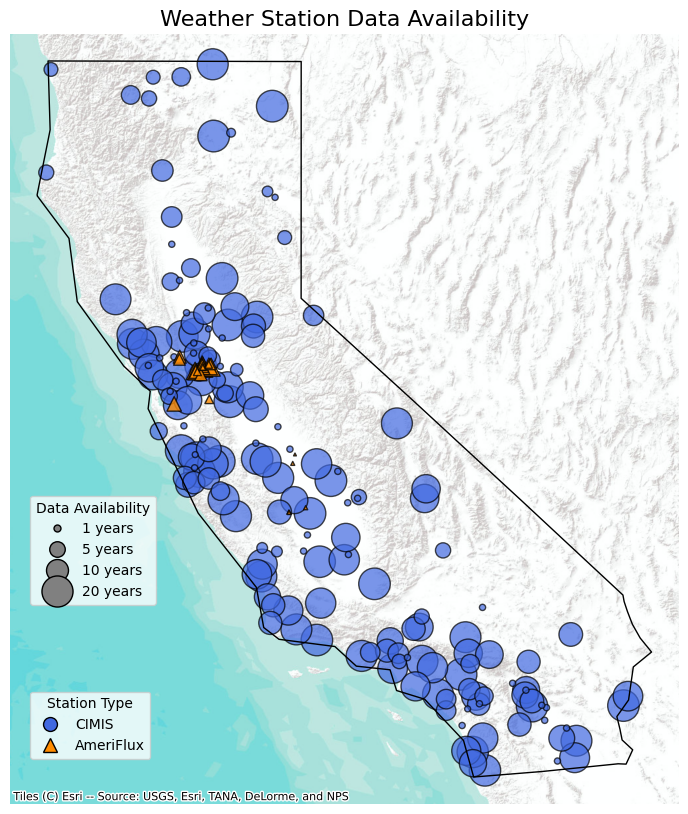

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D


# Convert dataframe to GeoDataFrame
gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["Longitude"],
        station_summary["Latitude"]
    ),
    crs="EPSG:4326"
)

# Project to web mercator
gdf = gdf.to_crs(epsg=3857)


fig, ax = plt.subplots(figsize=(10, 10))


# -----------------------------
# Plot CIMIS stations
# -----------------------------
cimis = gdf[gdf["Type"] == "CIMIS"]

cimis.plot(
    ax=ax,
    marker="o",
    color="royalblue",
    markersize=cimis["Years"]*20,
    alpha=0.7,
    edgecolor="black"
)


# -----------------------------
# Plot AmeriFlux stations
# -----------------------------
ameri = gdf[gdf["Type"] == "AmeriFlux"]

ameri.plot(
    ax=ax,
    marker="^",
    color="darkorange",
    markersize=ameri["Years"]*20,
    alpha=0.8,
    edgecolor="black"
)


# -----------------------------
# Add California boundary HERE
# -----------------------------

states = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_1_states_provinces.geojson"
)

california = states[
    (states.name == "California") &
    (states.admin == "United States of America")
]

california = california.to_crs(epsg=3857)

# Draw CA outline
california.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)


# -----------------------------
# Crop map to California HERE
# -----------------------------

xmin, ymin, xmax, ymax = california.total_bounds

# add a little padding around CA
pad = 50000

ax.set_xlim(xmin-pad, xmax+pad)
ax.set_ylim(ymin-pad, ymax+pad)


# -----------------------------
# Add basemap
# -----------------------------

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldTerrain
)


# Formatting
ax.set_axis_off()

plt.title(
    "Weather Station Data Availability",
    fontsize=16
)

from matplotlib.lines import Line2D

# -----------------------------
# Legend: data availability (top)
# -----------------------------

years_examples = [1, 5, 10, 20]

size_legend = []

for y in years_examples:
    size_legend.append(
        Line2D(
            [0], [0],
            marker="o",
            color="gray",
            label=f"{y} years",
            markerfacecolor="gray",
            markeredgecolor="black",
            markersize=(y**0.5)*5,
            linestyle=""
        )
    )

legend1 = ax.legend(
    handles=size_legend,
    title="Data Availability",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.25),  # move upward
    frameon=True
)

ax.add_artist(legend1)


# -----------------------------
# Legend: station type (bottom)
# -----------------------------

type_legend = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="CIMIS",
        markerfacecolor="royalblue",
        markeredgecolor="black",
        markersize=10,
        linestyle=""
    ),
    Line2D(
        [0], [0],
        marker="^",
        color="w",
        label="AmeriFlux",
        markerfacecolor="darkorange",
        markeredgecolor="black",
        markersize=10,
        linestyle=""
    )
]


ax.legend(
    handles=type_legend,
    title="Station Type",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.05),  # below data legend
    frameon=True
)

plt.show()